In [1]:
import scipy
print("SciPy version:", scipy.__version__)

SciPy version: 1.18.1


In [2]:
from scipy import stats
import numpy as np

data = [12, 15, 13, 12, 18, 20, 22, 21]

mean_val = np.mean(data)
median_val = np.median(data)
variance_val = stats.tvar(data)
std_val = stats.tstd(data)

print(f"Mean: {mean_val}")
print(f"Median: {median_val}")
print(f"Variance: {variance_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")

Mean: 16.625
Median: 16.5
Variance: 17.12
Standard Deviation: 4.14


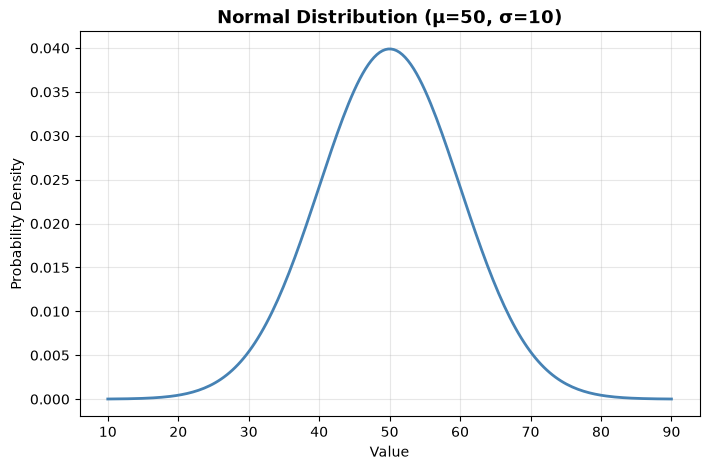

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma = 50, 10
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
pdf = norm.pdf(x, mu, sigma)

plt.figure(figsize=(8, 5))
plt.plot(x, pdf, color='steelblue', linewidth=2)
plt.title(f'Normal Distribution (μ={mu}, σ={sigma})', fontsize=13, fontweight='bold')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(alpha=0.3)
plt.show()

In [4]:
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)

t_stat, p_value = stats.ttest_ind(data1, data2)

print(f"Data1 mean: {data1.mean():.2f}")
print(f"Data2 mean: {data2.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("\nSignificant difference (reject H0)")
else:
    print("\nNo significant difference (fail to reject H0)")

Data1 mean: 50.63
Data2 mean: 62.04
T-statistic: -7.9613
P-value: 0.000000

Significant difference (reject H0)


In [5]:
campaign_a = np.array([2.5, 2.9, 3.0, 2.6, 2.8, 2.7, 3.1, 2.9])  # engagement %, one value per post
campaign_b = np.array([3.2, 3.6, 3.3, 3.5, 3.7, 3.1, 3.4, 3.6])

t_stat, p_value = stats.ttest_ind(campaign_a, campaign_b)
print(f"Campaign A mean: {campaign_a.mean():.2f}%")
print(f"Campaign B mean: {campaign_b.mean():.2f}%")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Campaign A mean: 2.81%
Campaign B mean: 3.43%
T-statistic: -5.8989
P-value: 0.0000


In [6]:
house_sizes = np.array([50, 70, 80, 100, 120])
house_prices = np.array([150000, 200000, 210000, 250000, 280000])

slope, intercept, r_value, p_value, std_err = stats.linregress(house_sizes, house_prices)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-value: {r_value:.4f}")

predicted_price = slope * 90 + intercept
print(f"\nPredicted price for a 90 sqm house: {predicted_price:,.2f}")

Slope: 1828.77
Intercept: 64383.56
R-value: 0.9942

Predicted price for a 90 sqm house: 228,972.60


**Exercise 5 interpretation:** The slope ($1,828.77/sqm) means each additional square meter adds about $1,829 to the predicted price. The R-value (0.9942) shows an extremely strong linear fit — house size explains almost all the price variation in this dataset. The 90 sqm prediction ($228,973) falls sensibly between the actual 80 sqm and 100 sqm prices.

In [7]:
fertilizer_1 = [5, 6, 7, 6, 5]
fertilizer_2 = [7, 8, 7, 9, 8]
fertilizer_3 = [4, 5, 4, 3, 4]

f_value, p_value = stats.f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)

print(f"Fertilizer 1 mean: {np.mean(fertilizer_1)}")
print(f"Fertilizer 2 mean: {np.mean(fertilizer_2)}")
print(f"Fertilizer 3 mean: {np.mean(fertilizer_3)}")
print(f"\nF-value: {f_value:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("\nSignificant difference between fertilizers (reject H0)")
else:
    print("\nNo significant difference between fertilizers (fail to reject H0)")

Fertilizer 1 mean: 5.8
Fertilizer 2 mean: 7.8
Fertilizer 3 mean: 4.0

F-value: 28.5263
P-value: 0.000028

Significant difference between fertilizers (reject H0)


**Exercise 6 answers:**

1. **F-value = 28.53, P-value = 0.000028.** The F-value compares how spread out the group *means* are from each other, relative to how much natural variation exists *within* each group. A high F-value (28.53 is quite large) means the differences between fertilizers are much bigger than the normal noise within each fertilizer's own results.

2. **Yes, significant.** Since p (0.000028) is far below the standard 0.05 threshold, we reject H0 — the fertilizers genuinely produce different growth results. Fertilizer 2 clearly performs best (mean 7.8 cm), Fertilizer 3 performs worst (mean 4.0 cm).

3. **If P-value > 0.05:** we would fail to reject H0, meaning we couldn't conclude the fertilizers actually differ in effectiveness — any observed differences in the sample means could plausibly be explained by random variation alone, and we'd need more data (or accept the fertilizers perform similarly) rather than recommending one over another.

In [8]:
from scipy.stats import binom

n, p = 10, 0.5  # 10 coin flips, 50% chance of heads each

prob_5_heads = binom.pmf(5, n, p)
print(f"Probability of exactly 5 heads in 10 flips: {prob_5_heads:.4f}")

# Bonus: full probability breakdown for 0-10 heads
for heads in range(n + 1):
    print(f"{heads} heads: {binom.pmf(heads, n, p):.4f}")

Probability of exactly 5 heads in 10 flips: 0.2461
0 heads: 0.0010
1 heads: 0.0098
2 heads: 0.0439
3 heads: 0.1172
4 heads: 0.2051
5 heads: 0.2461
6 heads: 0.2051
7 heads: 0.1172
8 heads: 0.0439
9 heads: 0.0098
10 heads: 0.0010


**Exercise 7:** The probability of exactly 5 heads in 10 fair coin flips is 24.61% — the single most likely outcome, but still less than a 1-in-4 chance. The full distribution is symmetric around 5 (since p=0.5), matching the classic bell-shaped binomial pattern for a fair coin.

In [9]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

data = pd.DataFrame({'age': [23, 25, 30, 35, 40], 'income': [35000, 40000, 50000, 60000, 70000]})

pearson_corr, pearson_p = pearsonr(data['age'], data['income'])
spearman_corr, spearman_p = spearmanr(data['age'], data['income'])

print(f"Pearson correlation: {pearson_corr:.4f} (p-value: {pearson_p:.4f})")
print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")

Pearson correlation: 0.9997 (p-value: 0.0000)
Spearman correlation: 1.0000 (p-value: 0.0000)


**Exercise 8:** Both correlations are nearly perfect (Pearson = 0.9997, Spearman = 1.0000). Spearman is exactly 1.0 because age and income increase together in the same order with zero exceptions — a perfect monotonic relationship. Pearson is fractionally below 1.0 because the increases aren't perfectly proportional at every step (a straight line would require identical income jumps per year of age), showing the subtle but real difference between the two correlation types even on nearly-identical data.